# **Week 2 Data Science Internship Assignment**

### **Missing Data Diagnosis • Outlier Handling • Advanced EDA**

---

## **Objective**

The objective of this notebook is to analyze the World Happiness Report dataset using advanced exploratory data analysis techniques. The notebook focuses on diagnosing missing values, selecting appropriate imputation strategies, identifying outliers, performing advanced EDA, and understanding introductory SQL concepts.

##**Importing and Cleaning Datasets**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.stats import zscore
from sklearn.impute import KNNImputer

import kagglehub

In [ ]:
path = kagglehub.dataset_download("unsdsn/world-happiness")

print(path)

Using Colab cache for faster access to the 'world-happiness' dataset.
/kaggle/input/world-happiness


In [ ]:
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

dfs = []

for file in csv_files:

    temp = pd.read_csv(os.path.join(path,file))

    temp["Year"]=file.replace(".csv","")

    dfs.append(temp)

df=pd.concat(dfs,ignore_index=True)


The datasets from 2015 to 2019 are merged into one DataFrame. A Year column is added so each observation can be traced back to its original year.

In [ ]:
df["Country_Final"]=(
    df["Country or region"]
    .fillna(df["Country"])
)

df["Happiness_Score"]=(
    df["Score"]
    .fillna(df["Happiness.Score"])
    .fillna(df["Happiness Score"])
)

df["GDP"]=(
    df["GDP per capita"]
    .fillna(df["Economy..GDP.per.Capita."])
    .fillna(df["Economy (GDP per Capita)"])
)

df["Health"]=(
    df["Healthy life expectancy"]
    .fillna(df["Health..Life.Expectancy."])
    .fillna(df["Health (Life Expectancy)"])
)

df["Freedom"]=(
    df["Freedom to make life choices"]
    .fillna(df["Freedom"])
)

df["Social_Support"]=(
    df["Social support"]
    .fillna(df["Family"])
)

df["Corruption"]=(
    df["Perceptions of corruption"]
    .fillna(df["Trust..Government.Corruption."])
    .fillna(df["Trust (Government Corruption)"])
)

In [ ]:
clean_df=df[
[
"Country_Final",
"Year",
"Happiness_Score",
"GDP",
"Social_Support",
"Health",
"Freedom",
"Generosity",
"Corruption"
]
]

In [ ]:
clean_df.head()

,Country_Final,Year,Happiness_Score,GDP,Social_Support,Health,Freedom,Generosity,Corruption
0,Switzerland,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [ ]:
clean_df.shape

(782, 9)

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country_Final    782 non-null    object 
 1   Year             782 non-null    object 
 2   Happiness_Score  782 non-null    float64
 3   GDP              782 non-null    float64
 4   Social_Support   782 non-null    float64
 5   Health           782 non-null    float64
 6   Freedom          782 non-null    float64
 7   Generosity       782 non-null    float64
 8   Corruption       781 non-null    float64
dtypes: float64(7), object(2)
memory usage: 55.1+ KB


##**PART C**

**Missing Data Diagnosis (M1)**

In [ ]:
clean_df.isnull().sum()

,0
Country_Final,0
Year,0
Happiness_Score,0
GDP,0
Social_Support,0
Health,0
Freedom,0
Generosity,0
Corruption,1


This command displays the total number of missing values in each column. Identifying missing values is an essential step before performing any statistical analysis or building machine learning models because missing data can affect the quality of results.

In [ ]:
(clean_df.isnull().sum()/len(clean_df)*100).round(2)

,0
Country_Final,0.00
Year,0.00
Happiness_Score,0.00
GDP,0.00
Social_Support,0.00
Health,0.00
Freedom,0.00
Generosity,0.00
Corruption,0.13


This command calculates the percentage of missing values in each column. Columns with a high percentage of missing values require careful handling, such as imputation or further investigation, before analysis.

**Missing Data Mechanism (M2)**

In [ ]:
clean_df.groupby(clean_df["Health"].isnull())["GDP"].mean()

,GDP
Health,
False,0.916047


This comparison checks whether missing values in the Health column are associated with changes in GDP. If the average GDP differs considerably between the two groups, the missingness may not be completely random and could indicate a relationship between variables.

In [ ]:
clean_df.groupby(clean_df["GDP"].isnull())["Happiness_Score"].mean()

,Happiness_Score
GDP,
False,5.379018



This analysis compares the average happiness score for records with and without missing GDP values. It helps determine whether the missing values follow a particular pattern instead of occurring randomly.

**Imputation Strategy (M3)**

In [ ]:
clean_df.isnull().sum()

,0
Country_Final,0
Year,0
Happiness_Score,0
GDP,0
Social_Support,0
Health,0
Freedom,0
Generosity,0
Corruption,1


In [ ]:
numeric_cols = clean_df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Happiness_Score', 'GDP', 'Social_Support', 'Health', 'Freedom',
       'Generosity', 'Corruption'],
      dtype='object')

In [ ]:
for col in numeric_cols:

    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

/tmp/ipykernel_1205/843863157.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df[col] = clean_df[col].fillna(clean_df[col].median())


In [ ]:
clean_df.isnull().sum()

,0
Country_Final,0
Year,0
Happiness_Score,0
GDP,0
Social_Support,0
Health,0
Freedom,0
Generosity,0
Corruption,0



Missing values in numerical columns were replaced using the median value of each column. Median imputation is preferred because it is less affected by extreme values and preserves the overall distribution of the data better than the mean.

In [ ]:
clean_df.describe()

,Happiness_Score,GDP,Social_Support,Health,Freedom,Generosity,Corruption
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125392
std,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105756
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054250
50%,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.091000
75%,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.155861
max,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910



After imputation, the dataset no longer contains missing numerical values. The summary statistics can be compared with earlier results to ensure that the imputation process did not significantly distort the overall distribution of the data.

In [ ]:
from sklearn.impute import KNNImputer

knn_df = clean_df.copy()

imputer = KNNImputer(n_neighbors=5)

knn_df[numeric_cols] = imputer.fit_transform(knn_df[numeric_cols])

knn_df.head()

,Country_Final,Year,Happiness_Score,GDP,Social_Support,Health,Freedom,Generosity,Corruption
0,Switzerland,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957



The KNN Imputer estimates missing values using the nearest neighboring observations based on similar feature values. This approach often provides more realistic estimates than using a single global statistic, especially when numerical variables are correlated.

**Outlier Handling**

**IQR Method (O1)**

In [ ]:
Q1 = clean_df["Happiness_Score"].quantile(0.25)
Q3 = clean_df["Happiness_Score"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = clean_df[
    (clean_df["Happiness_Score"] < lower_bound) |
    (clean_df["Happiness_Score"] > upper_bound)
]

print("Number of Outliers:", len(outliers_iqr))

In [ ]:
outliers_iqr.head()


The IQR method identifies observations that fall significantly below or above the normal range of happiness scores. These values are considered potential outliers and should be reviewed before deciding whether to remove or retain them.

**Visualizing Outliers**

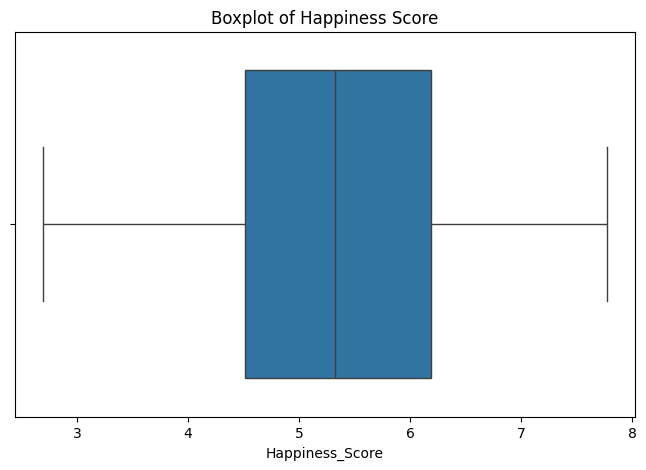

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(x=clean_df["Happiness_Score"])

plt.title("Boxplot of Happiness Score")

plt.show()


The boxplot visually highlights the spread of happiness scores and any observations outside the whiskers, which represent potential outliers detected by the IQR method.

**Z-Score Method (O2)**

In [ ]:
clean_df["Z_Score"] = zscore(clean_df["Happiness_Score"])

In [ ]:
z_outliers = clean_df[
    clean_df["Z_Score"].abs() > 3
]

print("Number of Z-Score Outliers:", len(z_outliers))

In [ ]:
z_outliers.head()


The Z-score method identifies values that are more than three standard deviations away from the mean. This method works best when the data is approximately normally distributed.

**Comparing Both Methods**

In [ ]:
print("IQR Outliers :", len(outliers_iqr))

print("Z-Score Outliers :", len(z_outliers))

### Interpretation

Comparing both methods helps determine which technique is more suitable for the dataset. The IQR method is generally more robust for skewed data, whereas the Z-score method performs better when the data follows a normal distribution.

**Business Decision (O3)**

In [ ]:
clean_df["Is_Outlier"] = (
    clean_df["Happiness_Score"] > upper_bound
)

In [ ]:
clean_df["Is_Outlier"].value_counts()


Rather than removing extreme observations, a new feature named **Is_Outlier** is created to flag unusually high happiness scores. These values may represent genuinely exceptional countries rather than errors, so retaining them preserves potentially valuable information.

In [ ]:
clean_df.head()


The dataset now includes two additional columns: **Z_Score** and **Is_Outlier**, which can be used for further analysis and visualization of unusual observations.

##**Part D - Advanced EDA Commands**

In [ ]:
clean_df.corr(numeric_only=True)


The correlation matrix shows the relationship between numerical variables. Positive values indicate that two variables increase together, while negative values indicate an inverse relationship.

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    clean_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


The heatmap provides a visual representation of correlations between numerical variables, making it easier to identify strong positive or negative relationships.

In [ ]:
pd.pivot_table(
    clean_df,
    values="Happiness_Score",
    index="Year",
    aggfunc="mean"
)


The pivot table summarizes the average happiness score for each year, allowing quick comparison across different years.

In [ ]:
clean_df.groupby(
    ["Year"]
).agg({
    "GDP":"mean",
    "Happiness_Score":"mean"
})


This aggregation calculates the average GDP and Happiness Score for each year, making yearly comparisons easier.

In [ ]:
clean_df["Country_Final"].str.contains("United").sum()


This command counts how many country names contain the word "United".

In [ ]:
clean_df.sort_values(
    ["Year","Happiness_Score"],
    ascending=[True,False]
)


Sorting by year and happiness score makes it easy to identify the happiest countries within each year.

In [ ]:
clean_df[
    (clean_df["GDP"]>1.5) &
    (clean_df["Happiness_Score"]>7)
]


This filter identifies countries with both high GDP and high happiness scores.

In [ ]:
clean_df.skew(numeric_only=True)


Skewness measures whether the distribution of numerical variables is symmetric or biased toward higher or lower values.

In [ ]:
clean_df.kurt(numeric_only=True)


Kurtosis measures the heaviness of the tails of the distribution and helps identify extreme values.

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Year",
    y="Happiness_Score",
    data=clean_df
)

plt.show()



The boxplot compares the distribution of happiness scores across different years and highlights potential outliers.

In [ ]:
sns.pairplot(
    clean_df[
        [
            "Happiness_Score",
            "GDP",
            "Health",
            "Freedom"
        ]
    ]
)

plt.show()



The pairplot visualizes relationships between multiple numerical variables simultaneously.

In [ ]:
clean_df.memory_usage(deep=True)



This command displays the memory consumed by each column, helping evaluate storage efficiency.

In [ ]:
optimized_df=clean_df.copy()

float_cols=optimized_df.select_dtypes(
    include="float64"
).columns

optimized_df[float_cols]=optimized_df[
    float_cols
].astype("float32")

optimized_df.info()



Downcasting numerical columns reduces memory usage while preserving the values.

In [ ]:
clean_df.groupby(
    "Year"
).size().sort_values(ascending=False)



This command counts the number of observations for each year.

In [ ]:
clean_df[
    "Year"
].value_counts(
    normalize=True
).cumsum()


The cumulative percentage shows how much of the dataset is represented as additional years are included.

In [ ]:
clean_df.describe()



The `describe()` command provides a statistical summary of all numerical columns, including count, mean, standard deviation, minimum, maximum, and quartiles. It helps understand the overall distribution of the data and identify any unusual values or potential outliers.

In [ ]:
clean_df.mean(numeric_only=True)


This command calculates the average value of each numerical column. The mean provides an overall measure of central tendency and helps compare the average values of different features in the dataset.

In [ ]:
clean_df.median(numeric_only=True)


The median represents the middle value of each numerical column when the data is sorted. Unlike the mean, it is less affected by extreme values, making it a reliable measure of central tendency for skewed data.

In [ ]:
clean_df.mode()


The `mode()` command identifies the most frequently occurring value in each column. It is particularly useful for understanding the most common category in categorical data and the most repeated value in numerical data.

In [ ]:
clean_df.nunique()


This command displays the number of unique values in each column. It helps identify columns with high variability, distinguish categorical and numerical features, and detect columns that may contain repeated values.

In [ ]:
clean_df.select_dtypes(include="number")


This command selects all numerical columns from the dataset. It is useful when performing statistical analysis, correlation calculations, or building machine learning models that require numerical features.

In [ ]:
clean_df.select_dtypes(include="object")


This command displays all categorical (object-type) columns in the dataset. These columns are useful for grouping, filtering, and analyzing qualitative information such as country names and years.

##**PART E - SQL Research Questions**

**Q1. What is SQL and why is it used with relational databases?**

SQL (Structured Query Language) is a programming language used to store, retrieve, update, and manage data in relational databases. It allows users to efficiently query large datasets and perform operations such as filtering, sorting, and aggregation.

**Q2. What do SELECT and WHERE do?**

The SELECT statement is used to retrieve specific columns from a table, while the WHERE clause filters rows based on a given condition.

Example:

SELECT Country, GDP

FROM Happiness

WHERE GDP > 1.5;

**Q3. What is a JOIN?**

A JOIN combines data from two or more related tables using a common column. It is useful when information is stored across multiple tables but needs to be analyzed together.

**Q4. What do GROUP BY and aggregate functions do?**

GROUP BY organizes rows into groups based on a column, while aggregate functions such as COUNT(), SUM(), and AVG() calculate summary statistics for each group.

**Q5. When would you use SQL instead of Pandas?**

I would use SQL when working with large datasets stored in relational databases because it retrieves only the required data efficiently. Pandas is more suitable after the data has been loaded into Python for analysis, visualization, and machine learning.